In [1]:
!pip install lightgbm --install-option=--gpu


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --install-option


In [2]:
!pip uninstall lightgbm -y
!pip install lightgbm --config-settings=cmake.define.USE_GPU=ON

Found existing installation: lightgbm 4.6.0
Uninstalling lightgbm-4.6.0:
  Successfully uninstalled lightgbm-4.6.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 40.0 MB/s eta 0:00:0000:0100:01


In [3]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import gc
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


In [4]:
print("Loading data...")
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')
test_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/test_transaction.csv')
test_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/test_identity.csv')

Loading data...


In [6]:
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test = test_transaction.merge(test_identity, on='TransactionID', how='left')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (590540, 434)
Test shape: (506691, 433)


In [7]:
target = train['isFraud']
train_id = train['TransactionID']
test_id = test['TransactionID']

# Drop target and ID columns
train = train.drop(['isFraud', 'TransactionID'], axis=1)
test = test.drop(['TransactionID'], axis=1)

In [8]:
print("Feature engineering...")

# Memory optimization - reduce memory usage
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    return df

Feature engineering...


In [9]:
train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

# Handle categorical features - only use columns that exist in both train and test
cat_features = [col for col in train.columns if train[col].dtype == 'object' and col in test.columns]
print(f"Categorical features: {len(cat_features)}")

Categorical features: 16


In [10]:
for col in cat_features:
    train[col] = train[col].fillna('unknown')
    test[col] = test[col].fillna('unknown')
    
    # Combine train and test for consistent encoding
    combined = pd.concat([train[col], test[col]], axis=0)
    train[col] = pd.Categorical(combined).codes[:len(train)]
    test[col] = pd.Categorical(combined).codes[len(train):]

# Ensure train and test have the same columns
common_cols = list(set(train.columns) & set(test.columns))
train = train[common_cols]
test = test[common_cols]
print(f"Using {len(common_cols)} common features")

Using 394 common features


In [11]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'device': 'gpu',
    'gpu_platform_id': 0,
    'gpu_device_id': 0,
    'num_leaves': 128,  # Reduced from 256
    'learning_rate': 0.05,  # Increased from 0.01 for faster convergence
    'feature_fraction': 0.5,  # Increased from 0.35
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': 8,  # Limited depth instead of -1
    'min_child_samples': 100,  # Increased from 20
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'seed': 42,
    'max_bin': 63  # Reduced from default 255 for speed
}

# K-Fold Cross Validation
n_folds = 3  # Reduced from 5 for faster training
folds = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

In [12]:
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))
feature_importance_df = pd.DataFrame()

print(f"\nStarting {n_folds}-Fold Cross Validation...")

for fold, (train_idx, val_idx) in enumerate(folds.split(train, target)):
    print(f"\n{'='*50}")
    print(f"Fold {fold + 1}/{n_folds}")
    print(f"{'='*50}")
    
    X_train, X_val = train.iloc[train_idx], train.iloc[val_idx]
    y_train, y_val = target.iloc[train_idx], target.iloc[val_idx]
    
    # Create LightGBM datasets
    lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cat_features)
    lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=cat_features, reference=lgb_train)
    
    # Train model
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=3000,  # Reduced from 10000
        valid_sets=[lgb_train, lgb_val],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),  # Reduced from 200
            lgb.log_evaluation(period=50)  # Reduced logging frequency
        ]
    )
    
    # Predictions
    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_preds += model.predict(test, num_iteration=model.best_iteration) / n_folds
    
    # Feature importance
    fold_importance = pd.DataFrame()
    fold_importance['feature'] = train.columns
    fold_importance['importance'] = model.feature_importance(importance_type='gain')
    fold_importance['fold'] = fold + 1
    feature_importance_df = pd.concat([feature_importance_df, fold_importance], axis=0)
    
    # Calculate fold AUC
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"\nFold {fold + 1} AUC: {fold_auc:.6f}")
    
    del X_train, X_val, y_train, y_val, lgb_train, lgb_val, model
    gc.collect()


Starting 3-Fold Cross Validation...

Fold 1/3


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 100 rounds
[50]	train's auc: 0.920906	valid's auc: 0.914762
[100]	train's auc: 0.938815	valid's auc: 0.928661
[150]	train's auc: 0.948282	valid's auc: 0.935461
[200]	train's auc: 0.954099	valid's auc: 0.939348
[250]	train's auc: 0.959202	valid's auc: 0.943024
[300]	train's auc: 0.963422	valid's auc: 0.945614
[350]	train's auc: 0.967228	valid's auc: 0.948264
[400]	train's auc: 0.971176	valid's auc: 0.950694
[450]	train's auc: 0.974619	valid's auc: 0.952879
[500]	train's auc: 0.976971	valid's auc: 0.954589
[550]	train's auc: 0.978815	valid's auc: 0.955773
[600]	train's auc: 0.98067	valid's auc: 0.956707
[650]	train's auc: 0.982395	valid's auc: 0.957924
[700]	train's auc: 0.983561	valid's auc: 0.958597
[750]	train's auc: 0.985117	valid's auc: 0.959645
[800]	train's auc: 0.986463	valid's auc: 0.960513
[850]	train's auc: 0.987757	valid's auc: 0.961443
[900]	train's auc: 0.988789	valid's auc: 0.962265
[950]	train's auc: 0.989673	valid's auc:

In [13]:
cv_auc = roc_auc_score(target, oof_preds)
print(f"\n{'='*50}")
print(f"Overall CV AUC: {cv_auc:.6f}")
print(f"{'='*50}\n")

# Feature importance analysis
feature_importance_df_agg = feature_importance_df.groupby('feature')['importance'].mean().reset_index()
feature_importance_df_agg = feature_importance_df_agg.sort_values('importance', ascending=False)
print("\nTop 20 Most Important Features:")
print(feature_importance_df_agg.head(20))

# Create submission file
submission = pd.DataFrame({
    'TransactionID': test_id,
    'isFraud': test_preds
})
submission.to_csv('submission.csv', index=False)
print("\nSubmission file created: submission.csv")

# Save feature importance
feature_importance_df_agg.to_csv('feature_importance.csv', index=False)
print("Feature importance saved: feature_importance.csv")


Overall CV AUC: 0.967672


Top 20 Most Important Features:
            feature    importance
221            V258  75411.414667
44    TransactionDT  36810.023601
387           card2  35528.329091
4               C13  34528.098784
386           card1  33716.102795
43   TransactionAmt  31491.946041
384           addr1  30977.983088
0                C1  27683.263527
29       DeviceInfo  26022.892686
5               C14  23603.362574
21               D2  19795.247375
287            V317  19114.289565
40    P_emaildomain  17177.185219
42    R_emaildomain  16677.406031
390           card5  16593.587847
20              D15  15541.807578
392           dist1  14960.183910
23               D4  11994.376650
2               C11  11697.330645
15              D10  11451.497203

Submission file created: submission.csv
Feature importance saved: feature_importance.csv



Overall CV AUC: 0.967672


Top 20 Most Important Features:
            feature    importance
221            V258  75411.414667
44    TransactionDT  36810.023601
387           card2  35528.329091
4               C13  34528.098784
386           card1  33716.102795
43   TransactionAmt  31491.946041
384           addr1  30977.983088
0                C1  27683.263527
29       DeviceInfo  26022.892686
5               C14  23603.362574
21               D2  19795.247375
287            V317  19114.289565
40    P_emaildomain  17177.185219
42    R_emaildomain  16677.406031
390           card5  16593.587847
20              D15  15541.807578
392           dist1  14960.183910
23               D4  11994.376650
2               C11  11697.330645
15              D10  11451.497203

Submission file created: submission.csv
Feature importance saved: feature_importance.csv

Generating ROC Curve...


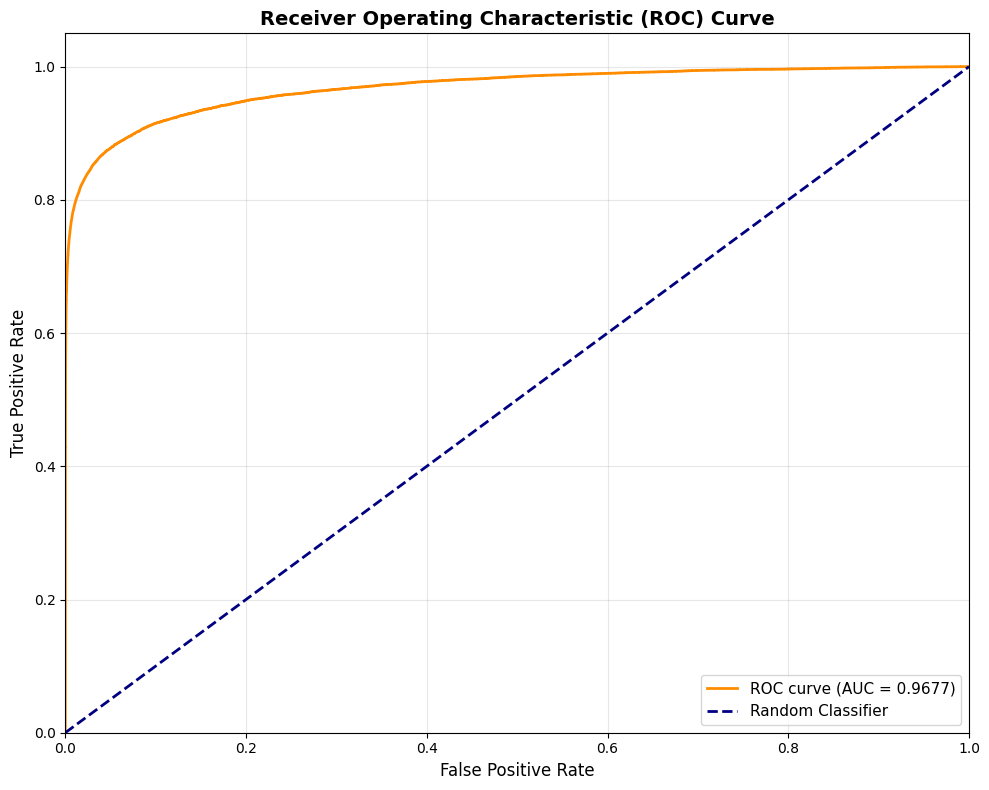

ROC curve saved: roc_curve.png

Optimal threshold: 0.0256

Generating Confusion Matrix...


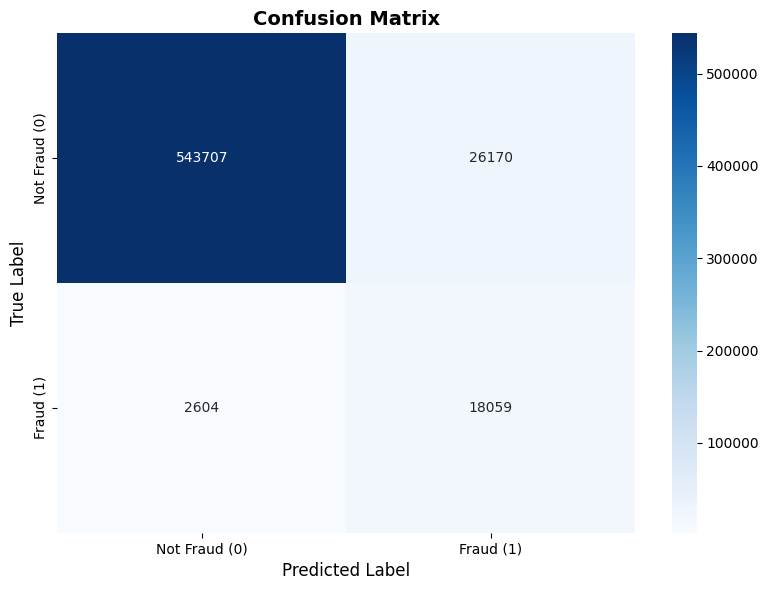

Confusion matrix saved: confusion_matrix.png

CONFUSION MATRIX BREAKDOWN
True Negatives:  543,707
False Positives: 26,170
False Negatives: 2,604
True Positives:  18,059

Precision:    0.4083
Recall:       0.8740
F1-Score:     0.5566
Specificity:  0.9541

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Not Fraud       1.00      0.95      0.97    569877
       Fraud       0.41      0.87      0.56     20663

    accuracy                           0.95    590540
   macro avg       0.70      0.91      0.77    590540
weighted avg       0.97      0.95      0.96    590540



In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
cv_auc = roc_auc_score(target, oof_preds)
print(f"\n{'='*50}")
print(f"Overall CV AUC: {cv_auc:.6f}")
print(f"{'='*50}\n")

# Feature importance analysis
feature_importance_df_agg = feature_importance_df.groupby('feature')['importance'].mean().reset_index()
feature_importance_df_agg = feature_importance_df_agg.sort_values('importance', ascending=False)
print("\nTop 20 Most Important Features:")
print(feature_importance_df_agg.head(20))

# Create submission file
submission = pd.DataFrame({
    'TransactionID': test_id,
    'isFraud': test_preds
})
submission.to_csv('submission.csv', index=False)
print("\nSubmission file created: submission.csv")

# Save feature importance
feature_importance_df_agg.to_csv('feature_importance.csv', index=False)
print("Feature importance saved: feature_importance.csv")

# Plot ROC Curve
print("\nGenerating ROC Curve...")
fpr, tpr, thresholds = roc_curve(target, oof_preds)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {cv_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("ROC curve saved: roc_curve.png")

# Find optimal threshold using Youden's J statistic
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nOptimal threshold: {optimal_threshold:.4f}")

# Generate predictions with optimal threshold
oof_preds_binary = (oof_preds >= optimal_threshold).astype(int)

# Confusion Matrix
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(target, oof_preds_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Fraud (0)', 'Fraud (1)'],
            yticklabels=['Not Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix saved: confusion_matrix.png")

# Print detailed metrics
print("\n" + "="*50)
print("CONFUSION MATRIX BREAKDOWN")
print("="*50)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

# Calculate additional metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nPrecision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1-Score:     {f1:.4f}")
print(f"Specificity:  {specificity:.4f}")

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(target, oof_preds_binary, target_names=['Not Fraud', 'Fraud']))